In [ ]:

!pip install ultralytics pyttsx3 opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.1/977.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

# Download YOLOv8
YOLO("yolov8n.pt")  # This will download the pretrained model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 278MB/s]


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [ ]:
import os
import json

# Define paths
image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train"
label_file = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Get file names without extensions
image_files = {os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))}

# Load COCO JSON and get labeled images
with open(label_file, "r") as f:
    coco_data = json.load(f)

# Extract labeled image names (without extensions)
label_files = {os.path.splitext(img["file_name"])[0] for img in coco_data["images"]}

# Remove unmatched images
for img in image_files - label_files:
    for ext in (".jpg", ".png", ".jpeg"):  # Check for multiple extensions
        image_path = os.path.join(image_dir, img + ext)
        if os.path.exists(image_path):
            os.remove(image_path)
            break  # Stop once the file is deleted

print("✅ Unmatched images removed successfully!")


✅ Unmatched images removed successfully!


In [ ]:
import os

# Define the directory containing images
image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"

# Iterate through files and fix filenames
for filename in os.listdir(image_dir):
    old_path = os.path.join(image_dir, filename)
    name, ext = os.path.splitext(filename)

    # If filename ends with an extra dot, rename it
    if name.endswith('.'):
        new_name = name.rstrip('.') + ext  # Keep original extension
        new_path = os.path.join(image_dir, new_name)

        # Rename the file
        os.rename(old_path, new_path)
        print(f"✅ Renamed: {filename} → {new_name}")


In [ ]:
import os
import json

# Define directories
image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"
label_file = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Get clean filenames (without extensions) from the image directory
image_files = {os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))}

# Load COCO JSON file and extract image names
with open(label_file, "r") as f:
    coco_data = json.load(f)

# Extract labeled image names (without extensions)
label_files = {os.path.splitext(img["file_name"])[0] for img in coco_data["images"]}

# Remove unmatched images
for img in image_files - label_files:
    for ext in (".jpg", ".png", ".jpeg"):  # Check for multiple extensions
        image_path = os.path.join(image_dir, img + ext)
        if os.path.exists(image_path):
            os.remove(image_path)
            print(f"🗑️ Deleted image: {image_path}")

print("✅ Cleanup complete! Only images in COCO JSON remain.")


✅ Cleanup complete! Only images in COCO JSON remain.


In [ ]:
import os
import json

# Define dataset directories
image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"
label_file = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Get filenames without extensions from image directory
image_files = {os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))}

# Load COCO JSON and extract labeled image names
with open(label_file, "r") as f:
    coco_data = json.load(f)

# Extract filenames (without extensions) from COCO JSON
label_files = {os.path.splitext(img["file_name"])[0] for img in coco_data["images"]}

# Find mismatches
images_without_labels = image_files - label_files
labels_without_images = label_files - image_files

# Print results
print(f"🖼️ Images without labels: {images_without_labels}")
print(f"📄 Labels without images: {labels_without_images}")

# Final check
if not images_without_labels and not labels_without_images:
    print("✅ Dataset is properly structured!")
else:
    print("⚠️ Some images or labels are missing. Please fix the dataset.")


🖼️ Images without labels: set()
📄 Labels without images: set()
✅ Dataset is properly structured!


In [ ]:
import os

image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"
image_filenames = os.listdir(image_dir)

print(f"Total images in directory: {len(image_filenames)}")
print("First 5 images:", image_filenames[:5])


Total images in directory: 5
First 5 images: ['000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg', '000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg', '000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg', '000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg', '000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg']


In [ ]:
import json

label_file = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Load the COCO JSON file
with open(label_file, "r") as f:
    coco_data = json.load(f)

# Print basic information
print("COCO JSON Keys:", coco_data.keys())  # Should include "images", "annotations", "categories"
print(f"Total Images in JSON: {len(coco_data.get('images', []))}")
print(f"Total Annotations: {len(coco_data.get('annotations', []))}")

# Print a sample image entry
if coco_data.get("images"):
    print("Sample Image Entry:", coco_data["images"][0])
else:
    print("❌ No images found in JSON!")


COCO JSON Keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Total Images in JSON: 5
Total Annotations: 61
Sample Image Entry: {'id': 0, 'license': 1, 'file_name': '000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg', 'height': 640, 'width': 640, 'date_captured': '2024-10-08T06:44:32+00:00', 'extra': {'user_tags': ['eval-images']}}


In [ ]:
import os

image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"

# List images in the directory
image_files = {f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png", ".jpeg"))}

# List images in COCO JSON
json_images = {img["file_name"] for img in coco_data.get("images", [])}

# Find missing files
missing_in_json = image_files - json_images
missing_in_folder = json_images - image_files

print(f"✅ Images in folder: {len(image_files)}")
print(f"✅ Images in JSON: {len(json_images)}")
print(f"❌ Images in folder but missing in JSON: {missing_in_json}")
print(f"❌ Images in JSON but missing in folder: {missing_in_folder}")


✅ Images in folder: 5
✅ Images in JSON: 5
❌ Images in folder but missing in JSON: set()
❌ Images in JSON but missing in folder: set()


In [ ]:
import os

# Root directory of your dataset
root_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix"

# Search for the missing image files
missing_images = [
    "000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg",
    "000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg",
    "000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg",
    "000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg",
    "000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg",
]

found_images = []

for root, _, files in os.walk(root_dir):
    for file in files:
        if file in missing_images:
            found_images.append(os.path.join(root, file))

# Print results
if found_images:
    print("✅ Found missing images:")
    for img in found_images:
        print(img)
else:
    print("❌ Missing images not found anywhere in the dataset!")


✅ Found missing images:
/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images/000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg
/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images/000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg
/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images/000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg
/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images/000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg
/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images/000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg


In [ ]:
import shutil

# Define paths
val_image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/val/images/"
train_image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images/"

# List of missing images
missing_images = [
    "000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg",
    "000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg",
    "000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg",
    "000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg",
    "000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg",
]

# Move files from val to train
for img in missing_images:
    src_path = os.path.join(val_image_dir, img)
    dest_path = os.path.join(train_image_dir, img)

    if os.path.exists(src_path):
        shutil.move(src_path, dest_path)
        print(f"✅ Moved {img} to train/images/")
    else:
        print(f"❌ {img} not found in val/images/")

print("✅ All missing images moved!")


❌ 000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg not found in val/images/
❌ 000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg not found in val/images/
❌ 000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg not found in val/images/
❌ 000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg not found in val/images/
❌ 000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg not found in val/images/
✅ All missing images moved!


In [ ]:
import json

# Load JSON
json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

with open(json_path, "r") as f:
    coco_data = json.load(f)

# Update image paths in JSON
for img in coco_data["images"]:
    if img["file_name"] in missing_images:
        img["file_name"] = f"../val/images/{img['file_name']}"  # Adjust path

# Save updated JSON
with open(json_path, "w") as f:
    json.dump(coco_data, f, indent=4)

print("✅ Updated JSON to correctly reference validation images!")


✅ Updated JSON to correctly reference validation images!


In [ ]:
import os
import json

# Define paths
image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"
json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Load JSON
with open(json_path, "r") as f:
    coco_data = json.load(f)

# Extract filenames from JSON
json_images = {img["file_name"] for img in coco_data["images"]}

# Extract actual image filenames from folder
actual_images = {f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))}

# Check mismatches
missing_in_folder = json_images - actual_images
missing_in_json = actual_images - json_images

print(f"✅ Images in folder: {len(actual_images)}")
print(f"✅ Images in JSON: {len(json_images)}")
print(f"❌ Images in JSON but missing in folder: {missing_in_folder}")
print(f"❌ Images in folder but missing in JSON: {missing_in_json}")

# Final check
if not missing_in_folder and not missing_in_json:
    print("✅ Dataset is correctly structured!")
else:
    print("⚠️ Some files are still mismatched. Consider fixing them before training.")


✅ Images in folder: 5
✅ Images in JSON: 5
❌ Images in JSON but missing in folder: {'../val/images/000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg', '../val/images/000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg', '../val/images/000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg', '../val/images/000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg', '../val/images/000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg'}
❌ Images in folder but missing in JSON: {'000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg', '000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg', '000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg', '000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg', '000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg'}
⚠️ Some files are still mismatched. Consider fixing them before training.


In [ ]:
import json

json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Load JSON
with open(json_path, "r") as f:
    coco_data = json.load(f)

# Check keys and structure
print("COCO JSON Keys:", coco_data.keys())
print("Total Images in JSON:", len(coco_data.get("images", [])))
print("Total Annotations:", len(coco_data.get("annotations", [])))

# Print some image entries
if "images" in coco_data and coco_data["images"]:
    print("Sample image entries:", coco_data["images"][:3])
else:
    print("❌ No images found in JSON!")


COCO JSON Keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Total Images in JSON: 5
Total Annotations: 61
Sample image entries: [{'id': 0, 'license': 1, 'file_name': '../val/images/000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg', 'height': 640, 'width': 640, 'date_captured': '2024-10-08T06:44:32+00:00', 'extra': {'user_tags': ['eval-images']}}, {'id': 1, 'license': 1, 'file_name': '../val/images/000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg', 'height': 640, 'width': 640, 'date_captured': '2024-10-08T06:44:32+00:00', 'extra': {'user_tags': ['eval-images']}}, {'id': 2, 'license': 1, 'file_name': '../val/images/000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg', 'height': 640, 'width': 640, 'date_captured': '2024-10-08T06:44:32+00:00', 'extra': {'user_tags': ['eval-images']}}]


In [ ]:
import os
import shutil
import random

# Define directories
val_image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/val/images"
train_image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"

# List all images in validation set
val_images = [f for f in os.listdir(val_image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Select random images to move
num_to_move = 5  # Change this number as needed
selected_images = random.sample(val_images, min(num_to_move, len(val_images)))

# Move images to train dataset
for img in selected_images:
    src_path = os.path.join(val_image_dir, img)
    dest_path = os.path.join(train_image_dir, img)
    shutil.copy(src_path, dest_path)
    print(f"✅ Copied {img} to train/images")

print("🚀 Image transfer complete!")


🚀 Image transfer complete!


In [ ]:
import os
import json
import shutil

# Define paths
val_json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/val/_annotations.coco.json"
train_json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

val_images_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/val/images"
train_images_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"

# Load validation JSON
with open(val_json_path, "r") as f:
    val_coco_data = json.load(f)

# Load or initialize train JSON
if os.path.exists(train_json_path):
    with open(train_json_path, "r") as f:
        train_coco_data = json.load(f)
else:
    train_coco_data = {"info": val_coco_data["info"], "licenses": val_coco_data["licenses"], "categories": val_coco_data["categories"], "images": [], "annotations": []}

# Select a subset of images (e.g., 5 images)
num_images_to_copy = 5
selected_images = val_coco_data["images"][:num_images_to_copy]

# Get the corresponding annotations
selected_image_ids = {img["id"] for img in selected_images}
selected_annotations = [ann for ann in val_coco_data["annotations"] if ann["image_id"] in selected_image_ids]

# Copy images to train directory
for img in selected_images:
    src_path = os.path.join(val_images_dir, img["file_name"])
    dest_path = os.path.join(train_images_dir, img["file_name"])

    if os.path.exists(src_path):
        shutil.copy(src_path, dest_path)
        print(f"✅ Copied: {img['file_name']}")

# Update train JSON
train_coco_data["images"].extend(selected_images)
train_coco_data["annotations"].extend(selected_annotations)

# Save updated train JSON
with open(train_json_path, "w") as f:
    json.dump(train_coco_data, f, indent=4)

print("✅ Train dataset updated successfully!")


✅ Train dataset updated successfully!


In [ ]:
import json

# Define the correct path for train JSON file
train_json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Load train JSON
with open(train_json_path, "r") as f:
    train_coco_data = json.load(f)

# Verify counts
print(f"✅ Total Images in Train JSON: {len(train_coco_data['images'])}")
print(f"✅ Total Annotations in Train JSON: {len(train_coco_data['annotations'])}")


✅ Total Images in Train JSON: 10
✅ Total Annotations in Train JSON: 122


In [ ]:
import os
import json

train_json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"
train_images_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"

# Load train JSON
with open(train_json_path, "r") as f:
    train_coco_data = json.load(f)

# Get image filenames from JSON
json_images = {img["file_name"] for img in train_coco_data["images"]}
folder_images = set(os.listdir(train_images_dir))

# Find mismatches
missing_in_folder = json_images - folder_images
missing_in_json = folder_images - json_images

print(f"✅ Images in folder: {len(folder_images)}")
print(f"✅ Images in JSON: {len(json_images)}")
print(f"❌ Images in JSON but missing in folder: {missing_in_folder}")
print(f"❌ Images in folder but missing in JSON: {missing_in_json}")


✅ Images in folder: 5
✅ Images in JSON: 10
❌ Images in JSON but missing in folder: {'../val/images/000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg', '../val/images/000000006763_jpg.rf.7aa7f75977c642cef2a56d5710e1859c.jpg', '../val/images/000000011122_jpg.rf.09c8ba84aae422561207a1efdbaa77ad.jpg', '../val/images/000000009400_jpg.rf.69c5b95fffbfbe70e3e0508c82d6baa2.jpg', '../val/images/000000006040_jpg.rf.aa5b3c3fc650ef74c3d5de49565876cf.jpg'}
❌ Images in folder but missing in JSON: set()


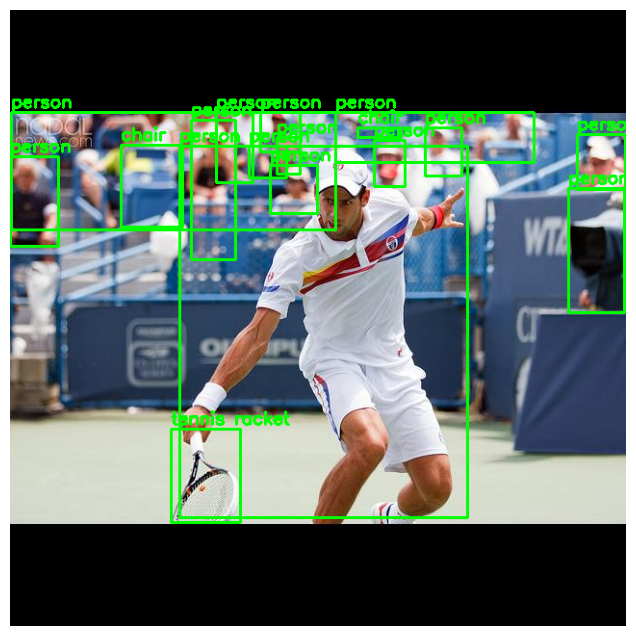

In [ ]:
import cv2
import json
import os
import random
import matplotlib.pyplot as plt

# Define paths
image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"
train_json_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Load JSON
with open(train_json_path, "r") as f:
    coco_data = json.load(f)

# Load class names
class_names = {cat["id"]: cat["name"] for cat in coco_data["categories"]}

# Select a random image
random_image_info = random.choice(coco_data["images"])
image_path = os.path.join(image_dir, random_image_info["file_name"])
image_id = random_image_info["id"]

# Ensure image exists
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

# Read image
image = cv2.imread(image_path)
if image is None:
    raise ValueError(f"Failed to load image: {image_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width, _ = image.shape

# Get annotations for the image
annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_id]

# Draw bounding boxes
for ann in annotations:
    x, y, w, h = ann["bbox"]
    class_id = ann["category_id"]

    # Convert COCO format to pixel coordinates
    x1, y1 = int(x), int(y)
    x2, y2 = int(x + w), int(y + h)

    # Draw rectangle
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, class_names[class_id], (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Show image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()


Image found: /content/drive/MyDrive/COCO_dataset/datasets/mix/train/images/000000126137_jpg.rf.d2e4766b996660bfc50aa67a47589dee.jpg
Image format: jpeg
PIL successfully loaded the image.
OpenCV successfully loaded the image.


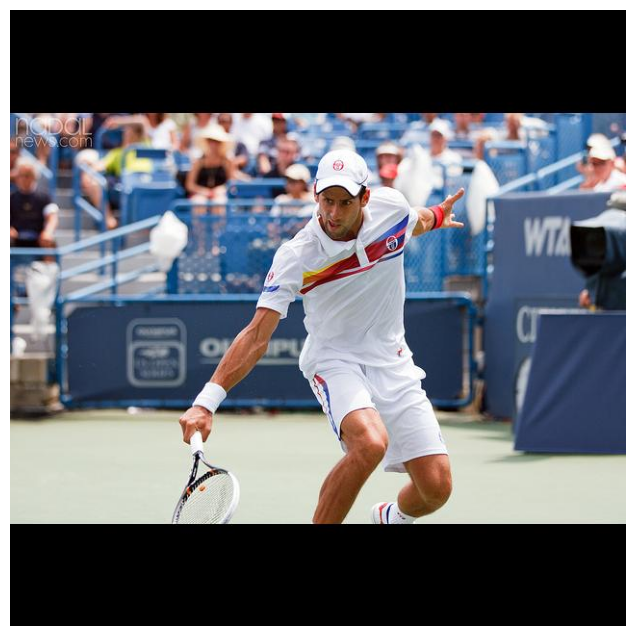

In [ ]:
import cv2
import os
import json
import random
import imghdr
import matplotlib.pyplot as plt
from PIL import Image

# Define paths
image_dir = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/images"
label_file = "/content/drive/MyDrive/COCO_dataset/datasets/mix/train/_annotations.coco.json"

# Load COCO annotations
with open(label_file, "r") as f:
    coco_data = json.load(f)

# Extract image filenames
image_info = coco_data["images"]
annotations = coco_data["annotations"]

# Select a random image
random_image_info = random.choice(image_info)
random_image_path = os.path.join(image_dir, random_image_info["file_name"])
image_id = random_image_info["id"]

# Debugging: Check if file exists
if not os.path.exists(random_image_path):
    raise FileNotFoundError(f"Image not found: {random_image_path}")
print(f"Image found: {random_image_path}")

# Debugging: Check image format
image_format = imghdr.what(random_image_path)
print(f"Image format: {image_format}")

# Try PIL (as a test)
try:
    pil_image = Image.open(random_image_path)
    pil_image.show()
    print("PIL successfully loaded the image.")
except Exception as e:
    print(f"PIL failed: {e}")

# Try OpenCV
image = cv2.imread(random_image_path, cv2.IMREAD_UNCHANGED)
if image is None:
    raise ValueError(f"OpenCV failed to load image: {random_image_path}")

print("OpenCV successfully loaded the image.")

# Convert BGR to RGB for Matplotlib
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display Image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()


In [ ]:
!apt update
!apt install -y espeak-ng


Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
64 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InR

In [ ]:
!espeak-ng "Hello, world!"


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
error: No such file or directory
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_

In [ ]:
!pip install pyttsx3


In [ ]:
!pip install gtts
from gtts import gTTS
import IPython.display as ipd


In [ ]:
text = "hello sai, how are you!"
tts = gTTS(text=text, lang="en")
tts.save("output.mp3")
ipd.display(ipd.Audio("output.mp3"))


In [ ]:
import pyttsx3

engine = pyttsx3.init()
engine.say("Object detected!")
engine.runAndWait()


In [ ]:
import cv2
import torch
import pyttsx3
from ultralytics import YOLO

# Load YOLO model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # Replace with your trained model

# Initialize Text-to-Speech engine
tts_engine = pyttsx3.init()
tts_engine.setProperty("rate", 150)  # Adjust speech speed

# Open webcam or video
cap = cv2.VideoCapture(0)  # Use 0 for webcam, or replace with video file

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO inference
    results = model(frame)

    # Extract detected class names
    detected_objects = set()
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]
            detected_objects.add(class_name)

            # Draw bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, class_name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Convert detected objects to speech
    if detected_objects:
        text_to_speak = " ".join(detected_objects)
        print(f"Detected: {text_to_speak}")
        tts_engine.say(text_to_speak)
        tts_engine.runAndWait()

    # Show frame
    cv2.imshow("YOLO Detection", frame)

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train/weights/best.pt'

In [ ]:
import cv2
from gtts import gTTS
import IPython.display as ipd
import torch
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# Load image
image_path = "/content/drive/MyDrive/COCO_dataset/datasets/mix/test/images/000000022199_jpg.rf.01dd5e5a1c56014391920651c25f9447.jpg"  # Change to your image path
image = cv2.imread(image_path)

# Perform object detection
results = model(image)

# Extract detected objects
detected_objects = []
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]  # Get class name
        detected_objects.append(class_name)

# Remove duplicates for better speech clarity
detected_objects = list(set(detected_objects))

# Convert detected objects to speech
if detected_objects:
    objects_text = ", ".join(detected_objects)
    speech_text = f"I detected the following objects: {objects_text}."
else:
    speech_text = "No objects detected."

# Generate speech
tts = gTTS(text=speech_text, lang="en")
tts.save("output.mp3")
ipd.display(ipd.Audio("output.mp3"))



0: 640x640 4 persons, 1 cup, 409.5ms
Speed: 7.1ms preprocess, 409.5ms inference, 15.5ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
import cv2
import torch
import time
import pyttsx3
from ultralytics import YOLO

# Initialize text-to-speech engine
engine = pyttsx3.init()
engine.setProperty("rate", 150)  # Adjust speech speed

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Use "yolov8n.pt" or your trained model

# Open webcam
cap = cv2.VideoCapture(0)  # Use 0 for default webcam, 1 for external cam

if not cap.isOpened():
    print("❌ Error: Could not open webcam!")
    exit()

# Track previously spoken objects to avoid repetition
last_spoken_objects = set()

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Error: Failed to grab frame")
        break

    # Perform object detection
    results = model(frame)

    # Extract detected objects
    detected_objects = set()  # Use set to avoid duplicates
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]  # Get class name
            detected_objects.add(class_name)

            # Draw bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0])  # Convert to integers
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 255, 0), 2)

    # Convert detected objects to speech only if they are new
    if detected_objects and detected_objects != last_spoken_objects:
        objects_text = ", ".join(detected_objects)
        speech_text = f"I see: {objects_text}."
        engine.say(speech_text)
        engine.runAndWait()
        last_spoken_objects = detected_objects  # Update last spoken objects

    # Show video feed with detections
    cv2.imshow("Real-Time Object Detection", frame)

    # Exit on pressing 'q'
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


❌ Error: Could not open webcam!
❌ Error: Failed to grab frame


In [ ]:
pip install opencv-python


In [ ]:
import cv2


In [ ]:
cap = cv2.VideoCapture(0) # Use 1 if USB webcam is plugged in


In [ ]:
import cv2

cap = cv2.VideoCapture(0)  # Use 1 or 2 for external webcams

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Failed to grab frame")
        break

    cv2.imshow("Webcam Test", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):  # Press 'q' to quit
        break

cap.release()
cv2.destroyAllWindows()


❌ Failed to grab frame


In [ ]:
import cv2

for i in range(5):  # Check up to 5 possible camera indexes
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"✅ Camera detected at index {i}")
        cap.release()
    else:
        print(f"❌ No camera at index {i}")


❌ No camera at index 0
❌ No camera at index 1
❌ No camera at index 2
❌ No camera at index 3
❌ No camera at index 4


In [ ]:
pip install --upgrade opencv-python


In [ ]:
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)


In [ ]:
import cv2

for i in range(5):  # Test camera indexes 0-4
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"✅ Camera detected at index {i}")
        cap.release()
    else:
        print(f"❌ No camera at index {i}")


❌ No camera at index 0
❌ No camera at index 1
❌ No camera at index 2
❌ No camera at index 3
❌ No camera at index 4


<IPython.core.display.Javascript object>

✅ Saved image: photo.jpg


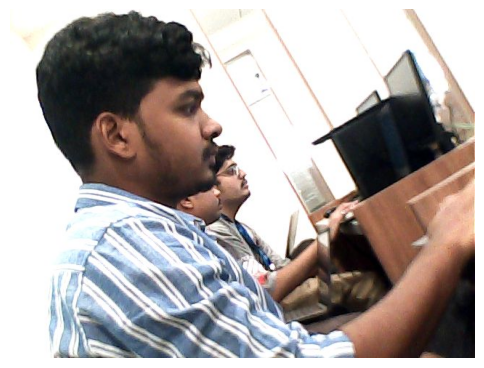

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
        const div = document.createElement('div');
        document.body.appendChild(div);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(video);
        video.srcObject = stream;
        await video.play();

        await new Promise(resolve => setTimeout(resolve, 10000));  // Wait 1 sec

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());

        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
    }
    takePhoto({quality});
    ''')

    display(js)
    data = eval_js("takePhoto({})".format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

filename = take_photo()
print(f"✅ Saved image: {filename}")

# Load image using OpenCV
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display without extra space
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")  # Remove axis to prevent extra space
plt.show()


<IPython.core.display.Javascript object>

📸 Image saved as photo.jpg


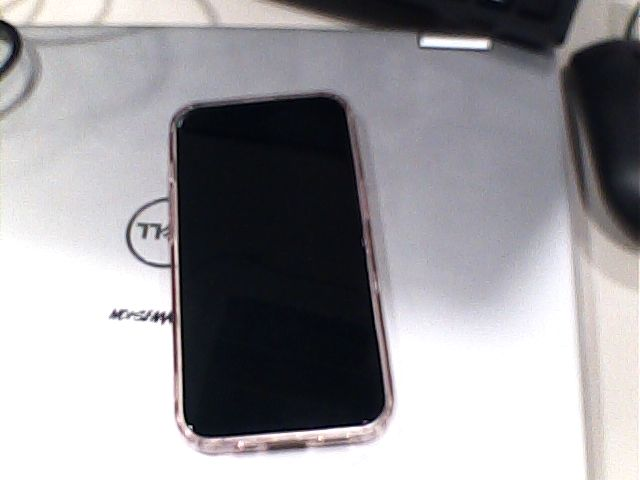

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture';

            div.appendChild(video);
            div.appendChild(button);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture an image
image_path = take_photo()
print(f"📸 Image saved as {image_path}")

# Display the image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
PIL.Image.fromarray(img_rgb)


<IPython.core.display.Javascript object>

📸 Image saved as photo.jpg


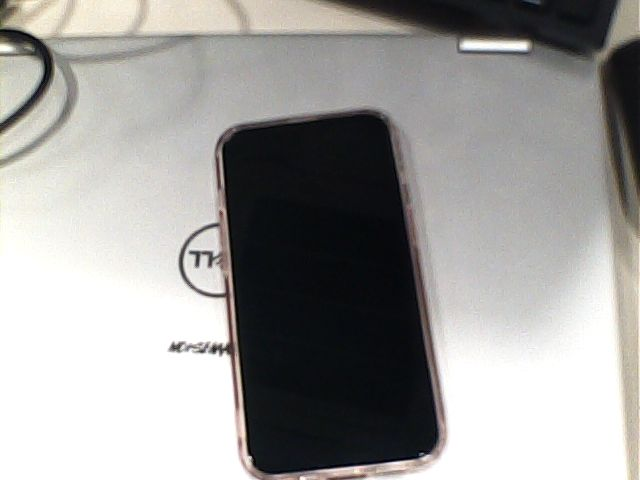

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture';

            div.appendChild(video);
            div.appendChild(button);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture an image
image_path = take_photo()
print(f"📸 Image saved as {image_path}")

# Display the image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
PIL.Image.fromarray(img_rgb)


In [ ]:
# Load a pre-trained YOLOv8 model (you can use 'yolov8n.pt' for a smaller model)
model = YOLO('yolov8n.pt')  # Using YOLOv8 Nano model


In [ ]:
from PIL import Image



0: 480x640 1 cell phone, 342.7ms
Speed: 7.3ms preprocess, 342.7ms inference, 31.0ms postprocess per image at shape (1, 3, 480, 640)
Detected objects: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potte

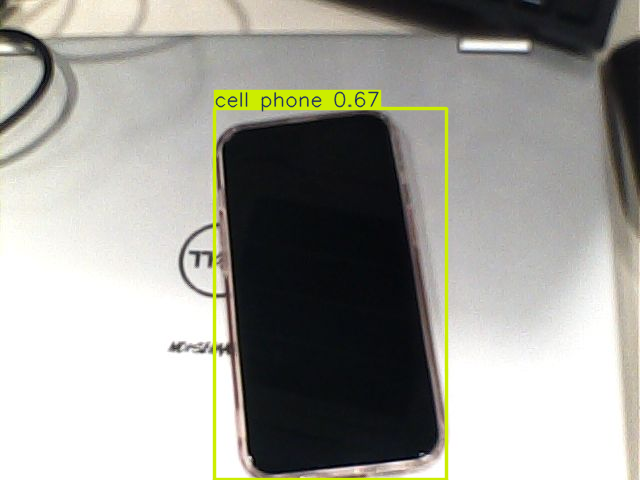

In [ ]:
# Load your captured image
image_path = "/content/photo.jpg"
img = Image.open(image_path)

# Run YOLOv8 object detection
results = model(img)

# Display detected objects
for result in results:
    print("Detected objects:", result.names)

# Show the detected image with bounding boxes
result.show()


In [ ]:
import pyttsx3

# Initialize text-to-speech engine
engine = pyttsx3.init()

# Get detected objects
detected_objects = [results[0].names[i] for i in results[0].boxes.cls.tolist()]

# Convert list to spoken text
if detected_objects:
    speech_text = "Detected objects: " + ", ".join(detected_objects)
    print(speech_text)
    engine.say(speech_text)
    engine.runAndWait()
else:
    print("No objects detected.")
    engine.say("No objects detected.")
    engine.runAndWait()


Detected objects: cell phone


In [ ]:
!pip install pyttsx3
!apt-get install espeak



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-data libespeak1 libportaudio2
The following NEW packages will be installed:
  espeak espeak-data libespeak1 libportaudio2
0 upgraded, 4 newly installed, 0 to remove and 64 not upgraded.
Need to get 1,371 kB of archives.
After this operation, 3,144 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudio2 amd64 19.6.0-1.1 [65.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 espeak-data amd64 1.48.15+dfsg-3 [1,085 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libespeak1 amd64 1.48.15+dfsg-3 [156 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 espeak amd64 1.48.15+dfsg-3 [64.2 kB]
Fetched 1,371 kB in 0s (9,342 kB/s)
Selecting previously unselected package libportaudio2:amd64.
(Reading database ... 125488 files and directories

In [ ]:
import pyttsx3
import time



In [ ]:
!pip install gtts


In [ ]:
import cv2
from gtts import gTTS
import IPython.display as ipd
import torch
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# Load image
image_path = "/content/photo.jpg"  # Change to your image path
image = cv2.imread(image_path)

# Perform object detection
results = model(image)

# Extract detected objects
detected_objects = []
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]  # Get class name
        detected_objects.append(class_name)

# Remove duplicates for better speech clarity
detected_objects = list(set(detected_objects))

# Convert detected objects to speech
if detected_objects:
    objects_text = ", ".join(detected_objects)
    speech_text = f"I detected the following objects: {objects_text}."
else:
    speech_text = "No objects detected."

# Generate speech
tts = gTTS(text=speech_text, lang="en")
tts.save("output1.mp3")
ipd.display(ipd.Audio("output1.mp3"))



0: 480x640 1 cell phone, 345.5ms
Speed: 3.2ms preprocess, 345.5ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io
from gtts import gTTS
import IPython.display as ipd
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture';

            div.appendChild(video);
            div.appendChild(button);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture an image
image_path = take_photo()
print(f"📸 Image saved as {image_path}")

# Load captured image
image = cv2.imread(image_path)

# Perform object detection
results = model(image)

# Extract detected objects
detected_objects = []
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]  # Get class name
        detected_objects.append(class_name)

# Remove duplicates for better speech clarity
detected_objects = list(set(detected_objects))



# Convert detected objects to speech
if detected_objects:
    objects_text = ", ".join(detected_objects)
    speech_text = f"I detected the following objects: {objects_text}."
else:
    speech_text = "No objects detected."

print(speech_text)

# Generate and play speech
tts = gTTS(text=speech_text, lang="en")
tts.save("output.mp3")
ipd.display(ipd.Audio("output.mp3"))


<IPython.core.display.Javascript object>

📸 Image saved as photo.jpg

0: 480x640 1 cup, 1 tv, 1 mouse, 1 remote, 1 cell phone, 206.0ms
Speed: 7.7ms preprocess, 206.0ms inference, 5.5ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: remote, tv, mouse, cup, cell phone.


<IPython.core.display.Javascript object>

📸 Image saved as photo.jpg

0: 480x640 1 keyboard, 3 cell phones, 186.3ms
Speed: 5.7ms preprocess, 186.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


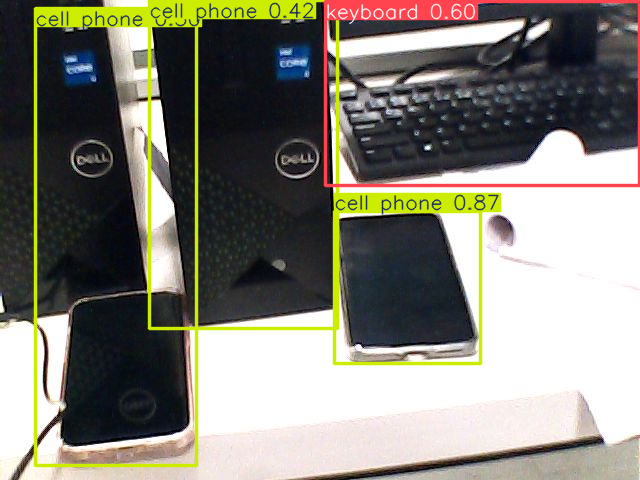

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io
from gtts import gTTS
import IPython.display as ipd
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# Function to capture an image
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture';

            div.appendChild(video);
            div.appendChild(button);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture image from webcam
image_path = take_photo()
print(f"📸 Image saved as {image_path}")

# Load the captured image
image = cv2.imread(image_path)
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run YOLOv8 object detection
results = model(image)

# Extract detected objects
detected_objects = []
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]  # Get class name
        detected_objects.append(class_name)

# Remove duplicates for better speech clarity
detected_objects = list(set(detected_objects))

# Convert detected objects to speech
if detected_objects:
    objects_text = ", ".join(detected_objects)
    speech_text = f"I detected the following objects: {objects_text}."
else:
    speech_text = "No objects detected."

# Generate speech
tts = gTTS(text=speech_text, lang="en")
tts.save("output.mp3")
ipd.display(ipd.Audio("output.mp3"))

# Show detected image with bounding boxes
for result in results:
    result.show()


<IPython.core.display.Javascript object>

📸 Image saved as photo.jpg

0: 480x640 1 clock, 270.9ms
Speed: 3.6ms preprocess, 270.9ms inference, 2.8ms postprocess per image at shape (1, 3, 480, 640)


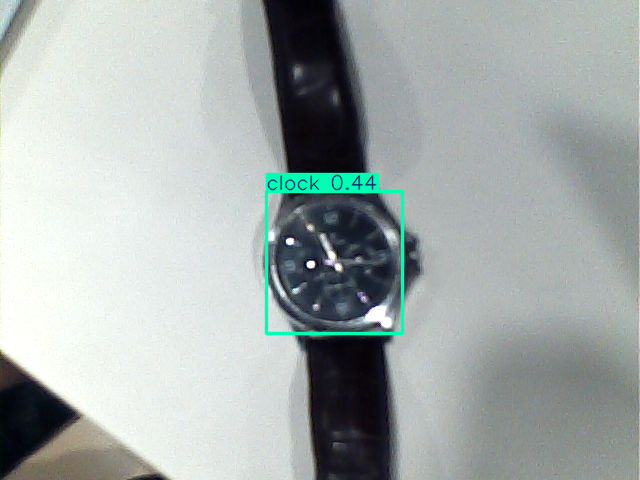

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import PIL.Image
import io
from gtts import gTTS
import IPython.display as ipd
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# Function to capture an image
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture';

            div.appendChild(video);
            div.appendChild(button);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Capture image from webcam
image_path = take_photo()
print(f"📸 Image saved as {image_path}")

# Load the captured image
image = cv2.imread(image_path)
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Run YOLOv8 object detection
results = model(image)

# Extract detected objects
detected_objects = []
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]  # Get class name
        detected_objects.append(class_name)

# Remove duplicates for better speech clarity
detected_objects = list(set(detected_objects))

# Convert detected objects to speech
if detected_objects:
    objects_text = ", ".join(detected_objects)
    speech_text = f"I detected the following objects: {objects_text}."
else:
    speech_text = "No objects detected."

# Generate speech
tts = gTTS(text=speech_text, lang="en")
tts.save("output.mp3")
ipd.display(ipd.Audio("output.mp3"))

# Show detected image with bounding boxes
for result in results:
    result.show()


<IPython.core.display.Javascript object>


0: 480x640 2 persons, 1 suitcase, 1 laptop, 1 cell phone, 191.9ms
Speed: 6.4ms preprocess, 191.9ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: suitcase, laptop, cell phone, person.


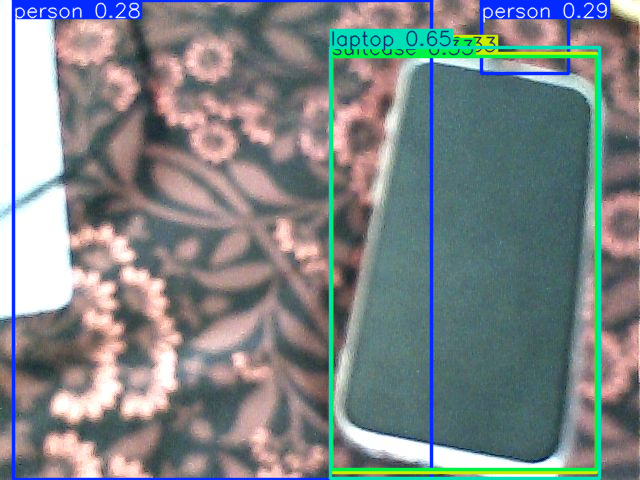


0: 480x640 1 suitcase, 1 laptop, 1 cell phone, 352.1ms
Speed: 3.2ms preprocess, 352.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: suitcase, laptop, cell phone.


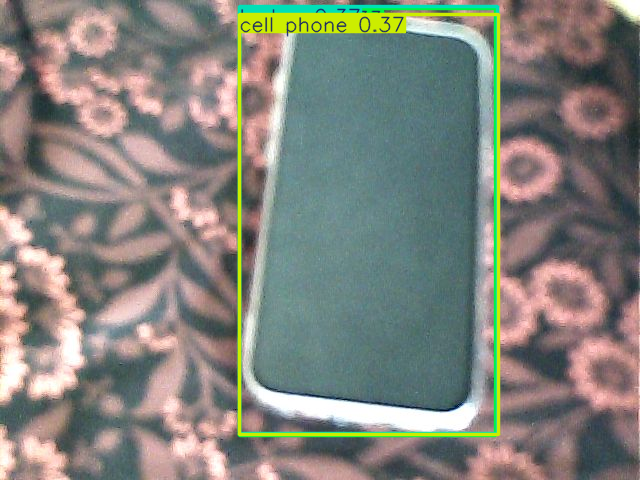


0: 480x640 1 person, 331.3ms
Speed: 3.1ms preprocess, 331.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: person.


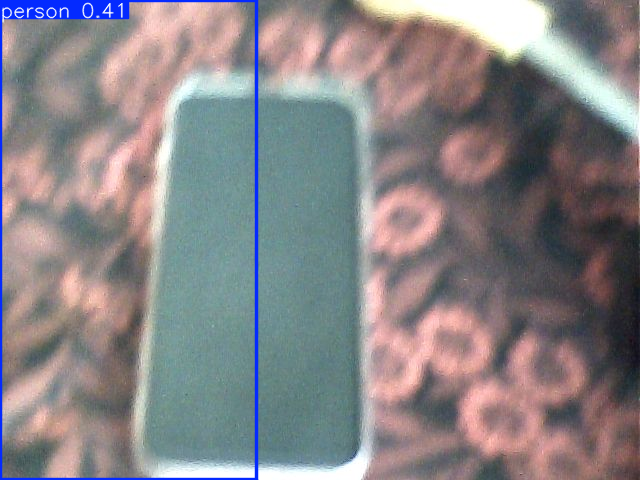


0: 480x640 1 cell phone, 323.6ms
Speed: 3.8ms preprocess, 323.6ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: cell phone.


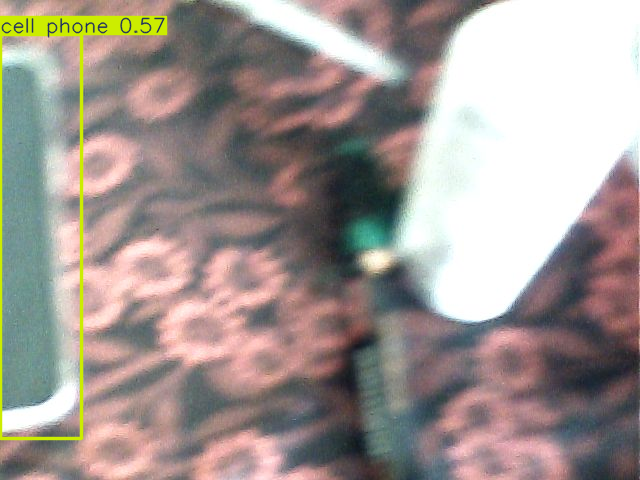


0: 480x640 (no detections), 326.1ms
Speed: 4.2ms preprocess, 326.1ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


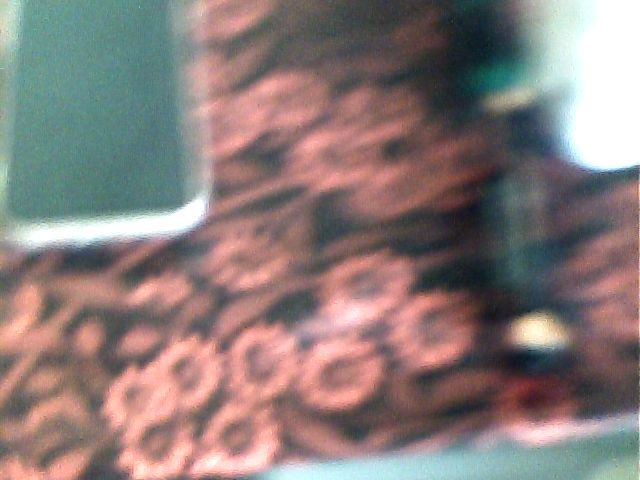


0: 480x640 1 cup, 375.8ms
Speed: 6.2ms preprocess, 375.8ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: cup.


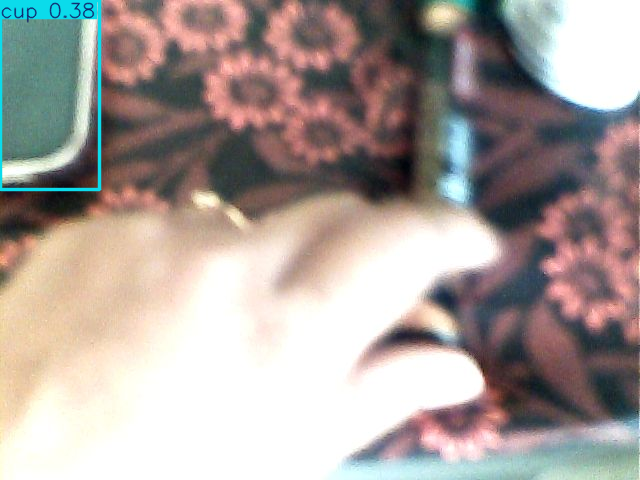


0: 480x640 (no detections), 341.1ms
Speed: 3.9ms preprocess, 341.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


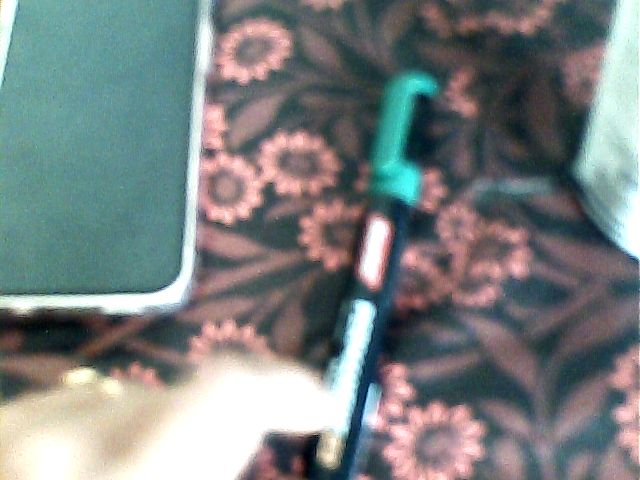


0: 480x640 (no detections), 316.9ms
Speed: 3.2ms preprocess, 316.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


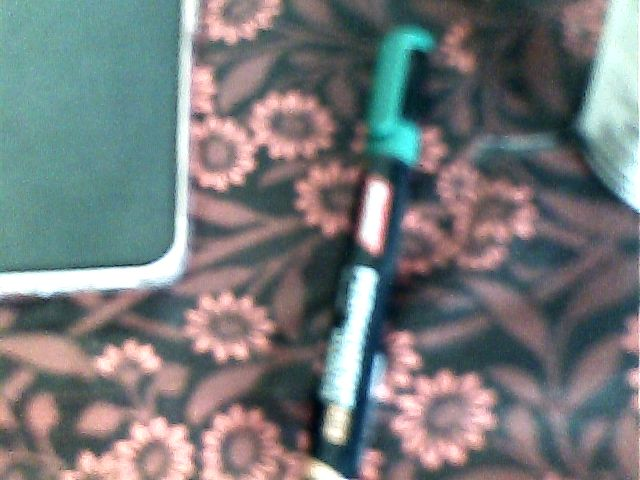


0: 480x640 (no detections), 339.0ms
Speed: 3.1ms preprocess, 339.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


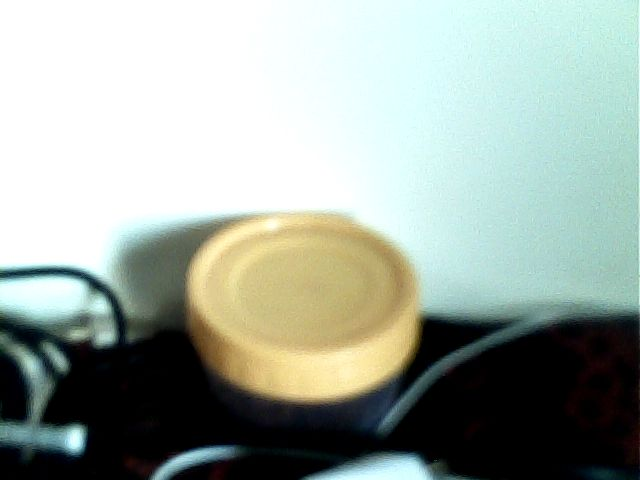


0: 480x640 1 bowl, 375.1ms
Speed: 11.2ms preprocess, 375.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: bowl.


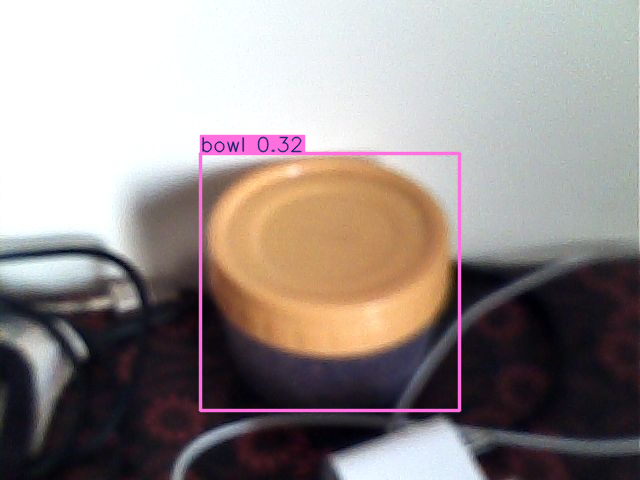


0: 480x640 (no detections), 349.2ms
Speed: 4.8ms preprocess, 349.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


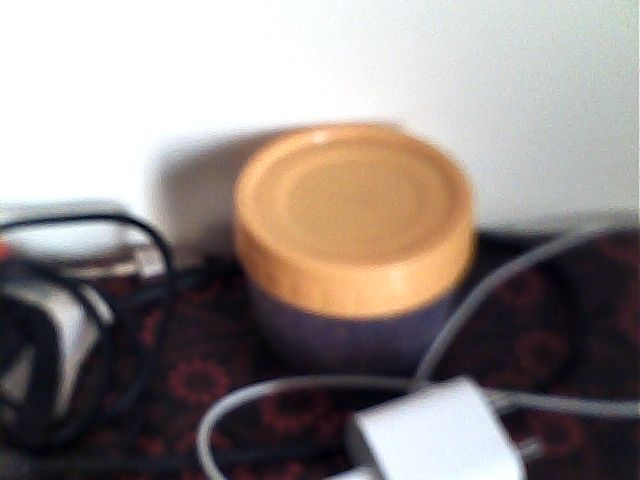


0: 480x640 (no detections), 261.0ms
Speed: 4.7ms preprocess, 261.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


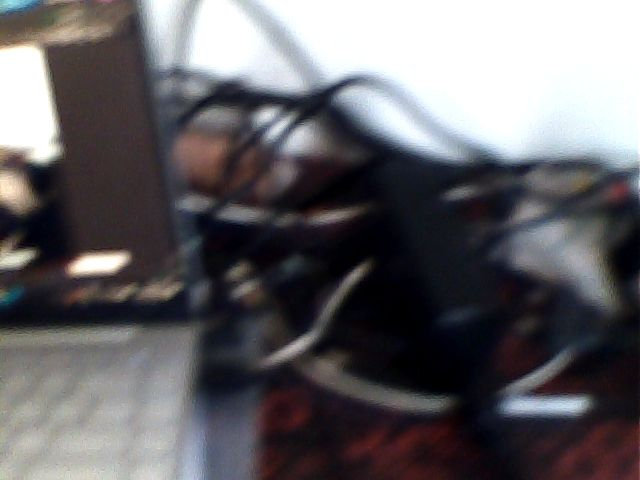


0: 480x640 1 person, 1 laptop, 243.3ms
Speed: 3.6ms preprocess, 243.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: laptop, person.


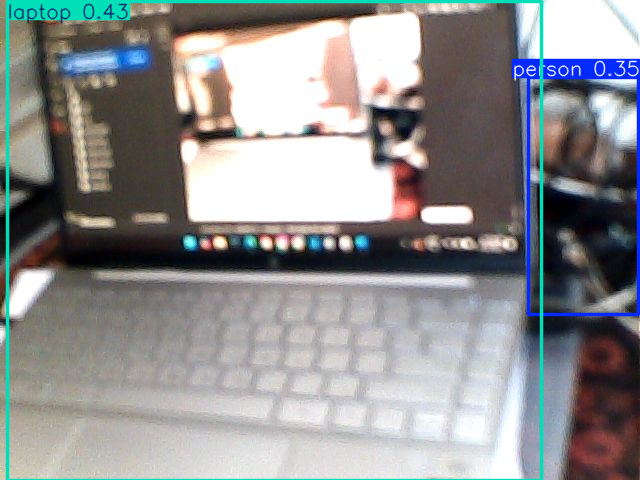


0: 480x640 (no detections), 223.6ms
Speed: 4.9ms preprocess, 223.6ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


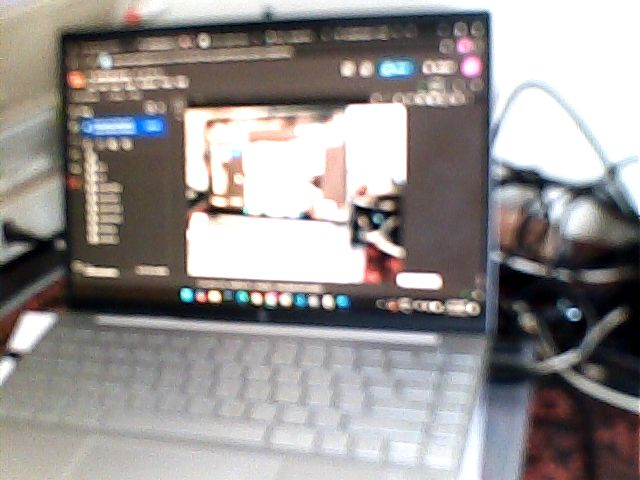


0: 480x640 (no detections), 229.9ms
Speed: 4.4ms preprocess, 229.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


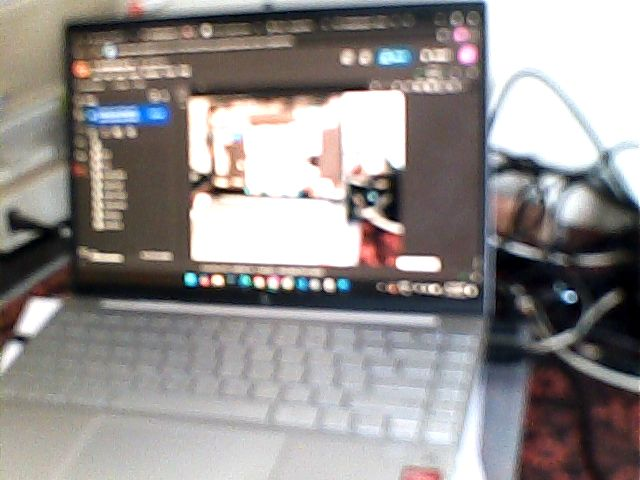


0: 480x640 (no detections), 227.0ms
Speed: 4.2ms preprocess, 227.0ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


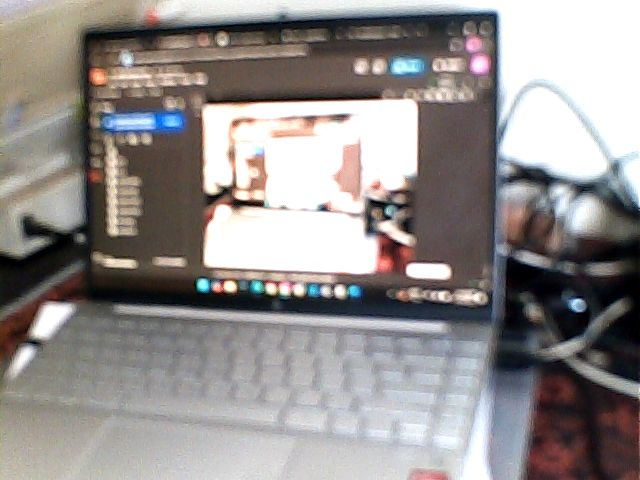


0: 480x640 1 laptop, 259.2ms
Speed: 7.0ms preprocess, 259.2ms inference, 6.0ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: laptop.


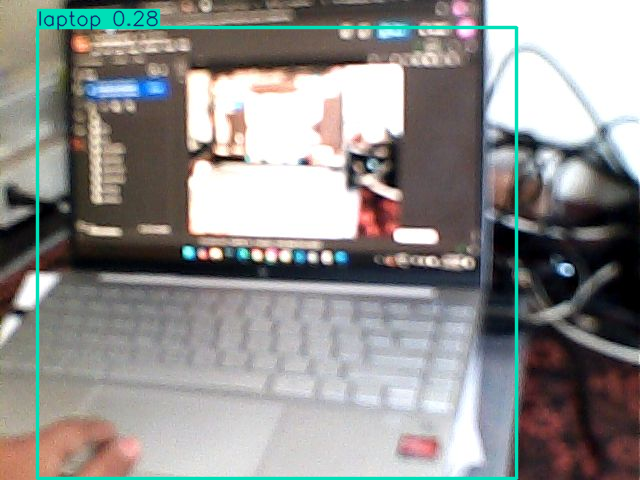


0: 480x640 1 person, 1 laptop, 241.8ms
Speed: 3.7ms preprocess, 241.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: laptop, person.


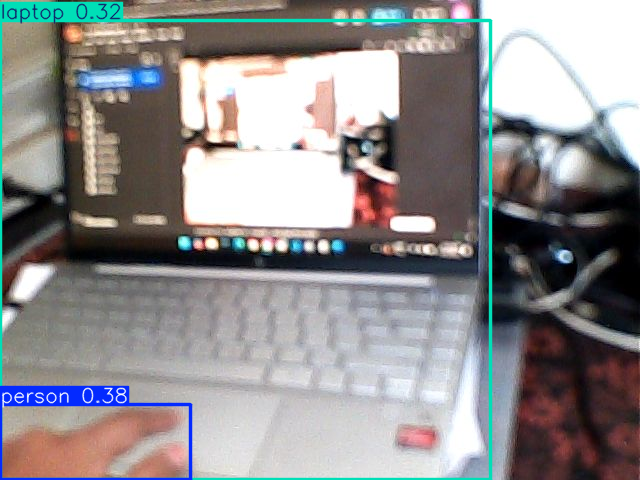


0: 480x640 1 person, 1 laptop, 228.1ms
Speed: 5.6ms preprocess, 228.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
I detected the following objects: laptop, person.


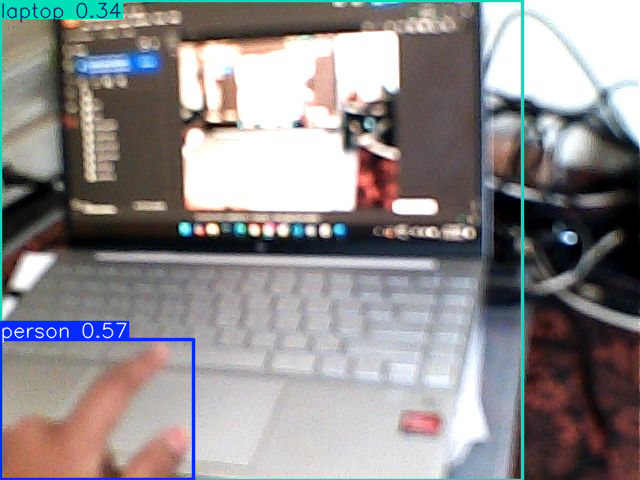

🛑 Stopping detection...
🛑 Stopping detection...


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from ultralytics import YOLO
import time
from google.colab import output

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# JavaScript to start and stop the webcam without capturing images explicitly
js = Javascript('''
    async function startCamera() {
        const video = document.createElement('video');
        const stopButton = document.createElement('button');
        stopButton.textContent = 'Stop Detection';

        document.body.appendChild(video);
        document.body.appendChild(stopButton);

        const stream = await navigator.mediaDevices.getUserMedia({ video: true });
        video.srcObject = stream;
        await video.play();

        function stopCamera() {
            stream.getTracks().forEach(track => track.stop());
            video.remove();
            stopButton.remove();
            google.colab.kernel.invokeFunction('notebook.stop_detection', [], {});
        }

        stopButton.onclick = stopCamera;

        while (true) {
            if (!document.body.contains(stopButton)) {
                stopCamera();
                break;
            }
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            const context = canvas.getContext('2d');
            context.drawImage(video, 0, 0);

            const dataUrl = canvas.toDataURL('image/jpeg', 0.8);
            google.colab.kernel.invokeFunction('notebook.detect_objects', [dataUrl], {});
            await new Promise(resolve => setTimeout(resolve, 1000));  // Process frame every second
        }
    }
''')

# Function to process frames without saving images
def detect_objects(image_data):
    binary = b64decode(image_data.split(',')[1])
    np_arr = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    # Perform object detection
    results = model(img)

    # Extract detected objects
    detected_objects = set()  # Use set to avoid duplicates
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            detected_objects.add(class_name)

    # Convert detected objects to speech
    if detected_objects:
        objects_text = ", ".join(detected_objects)
        speech_text = f"I detected the following objects: {objects_text}."
        print(speech_text)

        # Generate and play speech
        tts = gTTS(text=speech_text, lang="en")
        tts.save("output2.mp3")
        ipd.display(ipd.Audio("output2.mp3"))

    # Show the detected image with bounding boxes
    for result in results:
        result.show()

# Function to stop detection
def stop_detection():
    print("🛑 Stopping detection...")

# Register the callback functions
output.register_callback('notebook.detect_objects', detect_objects)
output.register_callback('notebook.stop_detection', stop_detection)

# Start real-time detection
display(js)
eval_js('startCamera()')


<IPython.core.display.Javascript object>


0: 480x640 8 persons, 1 backpack, 1 dining table, 1 tv, 1 laptop, 261.3ms
Speed: 4.3ms preprocess, 261.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
I detected: tv (unknown cm), laptop (unknown cm), person (unknown cm), dining table (unknown cm), backpack (unknown cm).


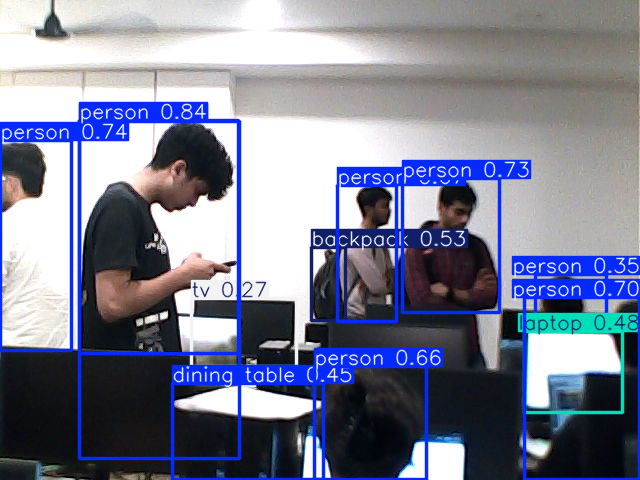

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change this to your trained model if needed

# Camera Calibration Constants (for Distance Calculation)
KNOWN_DISTANCE = 50  # cm (distance of reference object from camera)
KNOWN_WIDTH = 14  # cm (actual width of reference object, e.g., bottle)

# Function to calculate focal length using a reference image
def find_focal_length(known_distance, known_width, width_in_pixels):
    return (width_in_pixels * known_distance) / known_width

# Function to estimate distance of an object
def estimate_distance(focal_length, real_width, width_in_pixels):
    if width_in_pixels > 0:
        return (real_width * focal_length) / width_in_pixels
    return -1  # Invalid case

# JavaScript to capture an image
def take_photo():
    js = Javascript('''
        async function captureImage() {
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture Image';

            document.body.appendChild(video);
            document.body.appendChild(button);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            button.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    return eval_js("captureImage()")

# Capture image
image_data = take_photo()

# Convert the image from base64 to OpenCV format
binary = b64decode(image_data.split(',')[1])
np_arr = np.frombuffer(binary, dtype=np.uint8)
img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# Perform object detection
results = model(img)

# Extract detected objects and calculate distance
detected_objects = set()
distances = {}

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        detected_objects.add(class_name)

        # Ensure bounding box has valid coordinates
        if len(box.xyxy) > 0:
            x_min, y_min, x_max, y_max = box.xyxy[0]  # Unpack coordinates
            width_in_pixels = int(x_max - x_min)  # Bounding box width

            if class_name == "bottle":  # Example: Using bottle as reference
                focal_length = find_focal_length(KNOWN_DISTANCE, KNOWN_WIDTH, width_in_pixels)
                distance = estimate_distance(focal_length, KNOWN_WIDTH, width_in_pixels)
                distances[class_name] = round(distance, 2)

# Convert detected objects and distances to speech
if detected_objects:
    objects_text = ", ".join(f"{obj} ({distances.get(obj, 'unknown')} cm)" for obj in detected_objects)
    speech_text = f"I detected: {objects_text}."
    print(speech_text)

    # Generate and play speech
    tts = gTTS(text=speech_text, lang="en")
    tts.save("output.mp3")
    ipd.display(ipd.Audio("output.mp3"))

# Show the detected image with bounding boxes
for result in results:
    result.show()


<IPython.core.display.Javascript object>


0: 480x640 1 bottle, 1 knife, 176.7ms
Speed: 5.2ms preprocess, 176.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Detected bottle with width 167 pixels
Estimated distance of bottle: 50.0 cm
Detected knife with width 63 pixels
Estimated distance of knife: 132.53968253968253 cm
I detected: bottle (50.0 cm), knife (132.54 cm).


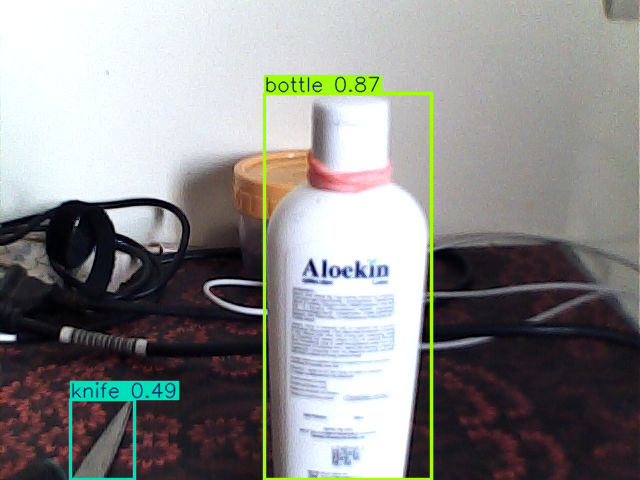

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change this to your trained model if needed

# Camera Calibration Constants (for Distance Calculation)
KNOWN_DISTANCE = 50  # cm (distance of reference object from camera)
KNOWN_WIDTH = 14  # cm (actual width of reference object, e.g., bottle)
ALERT_DISTANCE = 20  # cm (Threshold for alert)

# Function to calculate focal length using a reference image
def find_focal_length(known_distance, known_width, width_in_pixels):
    return (width_in_pixels * known_distance) / known_width

# Function to estimate distance of an object
def estimate_distance(focal_length, real_width, width_in_pixels):
    if width_in_pixels > 0:
        return (real_width * focal_length) / width_in_pixels
    return -1  # Invalid case

# JavaScript to capture an image
def take_photo():
    js = Javascript('''
        async function captureImage() {
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture Image';

            document.body.appendChild(video);
            document.body.appendChild(button);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            button.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    return eval_js("captureImage()")

# Capture image
image_data = take_photo()

# Convert the image from base64 to OpenCV format
binary = b64decode(image_data.split(',')[1])
np_arr = np.frombuffer(binary, dtype=np.uint8)
img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# Perform object detection
results = model(img)

# Extract detected objects and calculate distance
detected_objects = set()
distances = {}
alerts = []
focal_length = None  # Initialize focal length

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        detected_objects.add(class_name)

        # Ensure bounding box has valid coordinates
        if len(box.xyxy) > 0:
            x_min, y_min, x_max, y_max = box.xyxy[0].cpu().numpy()  # Convert to numpy
            width_in_pixels = int(x_max - x_min)  # Bounding box width

            if width_in_pixels > 0:  # Ensure valid width
                print(f"Detected {class_name} with width {width_in_pixels} pixels")  # Debugging print

                if focal_length is None:  # Calculate focal length once
                    focal_length = find_focal_length(KNOWN_DISTANCE, KNOWN_WIDTH, width_in_pixels)

                distance = estimate_distance(focal_length, KNOWN_WIDTH, width_in_pixels)
                distances[class_name] = round(distance, 2)

                print(f"Estimated distance of {class_name}: {distance} cm")  # Debugging print

                # If object is too close, add an alert
                if distance < ALERT_DISTANCE:
                    alerts.append(f"Alert! {class_name} is too close!")

# Convert detected objects and distances to speech
if alerts:
    speech_text = " ".join(alerts)  # Say all alerts
else:
    objects_text = ", ".join(f"{obj} ({distances.get(obj, 'unknown')} cm)" for obj in detected_objects)
    speech_text = f"I detected: {objects_text}."

print(speech_text)

# Generate and play speech
tts = gTTS(text=speech_text, lang="en")
tts.save("output.mp3")
ipd.display(ipd.Audio("output.mp3"))

# Show the detected image with bounding boxes
for result in results:
    result.show()


<IPython.core.display.Javascript object>


0: 480x640 1 laptop, 1 scissors, 173.8ms
Speed: 4.5ms preprocess, 173.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Detected scissors - Width: 215 px, Distance: 39.06976744186046 cm
Detected laptop - Width: 258 px, Distance: 32.55813953488372 cm
I detected: scissors (39.07 cm), laptop (32.56 cm).


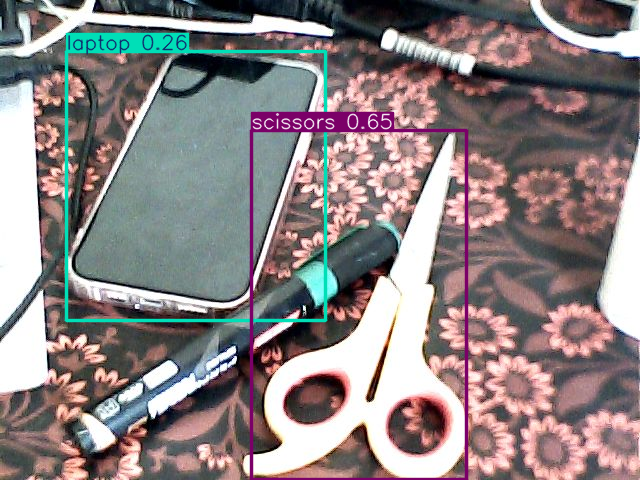

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change this to your trained model if needed

# Camera Calibration Constants
KNOWN_DISTANCE = 50  # cm (Pre-measured distance of reference object)
KNOWN_WIDTH = 14  # cm (Actual width of reference object, e.g., bottle)
ALERT_DISTANCE = 20  # cm (Threshold for alert)

# Precomputed focal length using a reference image
FOCAL_LENGTH = 600  # Manually calibrated based on a known object

# Function to estimate distance of an object
def estimate_distance(real_width, width_in_pixels):
    if width_in_pixels > 0:
        return (real_width * FOCAL_LENGTH) / width_in_pixels
    return -1  # Invalid case

# JavaScript to capture an image
def take_photo():
    js = Javascript('''
        async function captureImage() {
            const video = document.createElement('video');
            const button = document.createElement('button');
            button.textContent = 'Capture Image';

            document.body.appendChild(video);
            document.body.appendChild(button);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            button.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    return eval_js("captureImage()")

# Capture image
image_data = take_photo()

# Convert the image from base64 to OpenCV format
binary = b64decode(image_data.split(',')[1])
np_arr = np.frombuffer(binary, dtype=np.uint8)
img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# Perform object detection
results = model(img)

# Extract detected objects and calculate distance
detected_objects = []
distances = {}
alerts = []

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        detected_objects.append(class_name)

        # Ensure bounding box has valid coordinates
        if len(box.xyxy) > 0:
            x_min, y_min, x_max, y_max = box.xyxy[0].cpu().numpy()  # Convert to numpy
            width_in_pixels = int(x_max - x_min)  # Bounding box width

            if width_in_pixels > 0:  # Ensure valid width
                distance = estimate_distance(KNOWN_WIDTH, width_in_pixels)
                distances[class_name] = round(distance, 2)

                print(f"Detected {class_name} - Width: {width_in_pixels} px, Distance: {distance} cm")  # Debugging print

                # If object is too close, add an alert
                if distance < ALERT_DISTANCE:
                    alerts.append(f"Alert! {class_name} is too close!")

# Convert detected objects and distances to speech
if alerts:
    speech_text = " ".join(alerts)  # Say all alerts
else:
    objects_text = ", ".join(f"{obj} ({distances.get(obj, 'unknown')} cm)" for obj in detected_objects)
    speech_text = f"I detected: {objects_text}."

print(speech_text)

# Generate and play speech
tts = gTTS(text=speech_text, lang="en")
tts.save("output.mp3")
ipd.display(ipd.Audio("output.mp3"))

# Show the detected image with bounding boxes
for result in results:
    result.show()


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from base64 import b64decode
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change this to your trained model if needed

# Camera Calibration Constants
KNOWN_DISTANCE = 50  # cm (Pre-measured distance of reference object)
KNOWN_WIDTH = 14  # cm (Actual width of reference object, e.g., bottle)
ALERT_DISTANCE = 20  # cm (Threshold for alert)

# Precomputed focal length (adjust based on tests)
FOCAL_LENGTH = 600  # Manually calibrated

# Function to estimate object distance
def estimate_distance(real_width, width_in_pixels):
    if width_in_pixels > 0:
        return (real_width * FOCAL_LENGTH) / width_in_pixels
    return -1  # Invalid case

# JavaScript to continuously stream video from webcam
def video_stream():
    js = Javascript('''
        async function startStreaming() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const context = canvas.getContext('2d');
            const stopButton = document.createElement('button');

            stopButton.textContent = 'Stop Detection';
            document.body.appendChild(video);
            document.body.appendChild(stopButton);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            function stopCamera() {
                stream.getTracks().forEach(track => track.stop());
                video.remove();
                stopButton.remove();
                google.colab.kernel.invokeFunction('notebook.stop_detection', [], {});
            }

            stopButton.onclick = stopCamera;

            while (true) {
                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                context.drawImage(video, 0, 0);

                const dataUrl = canvas.toDataURL('image/jpeg', 0.8);
                google.colab.kernel.invokeFunction('notebook.process_frame', [dataUrl], {});

                await new Promise(resolve => setTimeout(resolve, 500)); // Process every 500ms

                if (!document.body.contains(stopButton)) {
                    stopCamera();
                    break;
                }
            }
        }
    ''')
    display(js)

# Function to process a frame and perform object detection
def process_frame(image_data):
    binary = b64decode(image_data.split(',')[1])
    np_arr = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    # Perform object detection
    results = model(img)
    detected_objects = []
    alerts = []

    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            detected_objects.append(class_name)

            # Ensure bounding box has valid coordinates
            if len(box.xyxy) > 0:
                x_min, y_min, x_max, y_max = box.xyxy[0].cpu().numpy()
                width_in_pixels = int(x_max - x_min)  # Bounding box width

                if width_in_pixels > 0:
                    distance = estimate_distance(KNOWN_WIDTH, width_in_pixels)

                    print(f"Detected {class_name} - Distance: {distance:.2f} cm")  # Debugging print

                    # Trigger an alert if the object is too close
                    if distance < ALERT_DISTANCE:
                        alerts.append(f"Alert! {class_name} is too close!")

    # Convert detected objects and distances to speech
    if alerts:
        speech_text = " ".join(alerts)  # Say all alerts
    else:
        speech_text = None  # No need to announce anything

    # Play speech alert only if there's an alert
    if speech_text:
        print(speech_text)  # Print to console
        tts = gTTS(text=speech_text, lang="en")
        tts.save("alert.mp3")
        ipd.display(ipd.Audio("alert.mp3"))

# Callback function for processing frames
from google.colab import output
output.register_callback('notebook.process_frame', process_frame)

# Callback function to stop detection
def stop_detection():
    print("Detection stopped.")

output.register_callback('notebook.stop_detection', stop_detection)

# Start real-time object detection
video_stream()


<IPython.core.display.Javascript object>

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from base64 import b64decode
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# Camera Calibration Constants
KNOWN_DISTANCE = 50  # cm (Pre-measured distance of reference object)
KNOWN_WIDTH = 14  # cm (Actual width of reference object, e.g., bottle)
ALERT_DISTANCE = 20  # cm (Threshold for alert)
FOCAL_LENGTH = 600  # Adjust based on tests

# Function to estimate object distance
def estimate_distance(real_width, width_in_pixels):
    if width_in_pixels > 0:
        return (real_width * FOCAL_LENGTH) / width_in_pixels
    return -1  # Invalid case

# JavaScript to capture a single image from the webcam
def take_photo():
    js = Javascript('''
        async function captureImage() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const button = document.createElement('button');

            button.textContent = 'Capture';
            document.body.appendChild(video);
            document.body.appendChild(button);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise(resolve => button.onclick = resolve);

            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            button.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    return eval_js('captureImage()')

# Capture image
image_data = take_photo()

# Convert image data to OpenCV format
binary = b64decode(image_data.split(',')[1])
np_arr = np.frombuffer(binary, dtype=np.uint8)
img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# Perform object detection
results = model(img)
detected_objects = []
alerts = []

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        detected_objects.append(class_name)

        # Ensure bounding box has valid coordinates
        if len(box.xyxy) > 0:
            x_min, y_min, x_max, y_max = box.xyxy[0].cpu().numpy()
            width_in_pixels = int(x_max - x_min)  # Bounding box width

            if width_in_pixels > 0:
                distance = estimate_distance(KNOWN_WIDTH, width_in_pixels)

                print(f"Detected {class_name} - Distance: {distance:.2f} cm")  # Debugging print

                # Trigger an alert if the object is too close
                if distance < ALERT_DISTANCE:
                    alerts.append(f"Alert! {class_name} is too close!")

# Convert detected objects and distances to speech
if alerts:
    speech_text = " ".join(alerts)  # Say all alerts
else:
    speech_text = "No nearby objects detected."

# Play speech alert
print(speech_text)  # Print to console
tts = gTTS(text=speech_text, lang="en")
tts.save("alert.mp3")
ipd.display(ipd.Audio("alert.mp3"))


<IPython.core.display.Javascript object>


0: 480x640 1 suitcase, 1 bottle, 1 remote, 169.2ms
Speed: 3.5ms preprocess, 169.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Detected remote - Distance: 50.00 cm
Detected suitcase - Distance: 22.95 cm
Detected bottle - Distance: 47.73 cm
No nearby objects detected.


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from base64 import b64decode
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# JavaScript to capture a single image from the webcam
def take_photo():
    js = Javascript('''
        async function captureImage() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const button = document.createElement('button');

            button.textContent = 'Capture';
            document.body.appendChild(video);
            document.body.appendChild(button);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise(resolve => button.onclick = resolve);

            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            button.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    return eval_js('captureImage()')

# Capture image
image_data = take_photo()

# Convert image data to OpenCV format
binary = b64decode(image_data.split(',')[1])
np_arr = np.frombuffer(binary, dtype=np.uint8)
img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# Perform object detection
results = model(img)
detected_objects = []

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        detected_objects.append(class_name)

# Convert detected objects to speech
if detected_objects:
    objects_text = ", ".join(detected_objects)
    speech_text = f"Alert! object is  {objects_text}. detected"
else:
    speech_text = "No objects detected."

# Play speech alert
print(speech_text)  # Print to console
tts = gTTS(text=speech_text, lang="en")
tts.save("alert.mp3")
ipd.display(ipd.Audio("alert.mp3"))


<IPython.core.display.Javascript object>


0: 480x640 1 sports ball, 1 bottle, 1 donut, 309.8ms
Speed: 5.3ms preprocess, 309.8ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Alert! object is  bottle, donut, sports ball. detected


In [ ]:
!pip install pytesseract
!apt-get install -y tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 37 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 0s (12.4 MB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 127075 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-e

In [ ]:
!apt-get install -y tesseract-ocr
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
import torch
from gtts import gTTS
import IPython.display as ipd
from base64 import b64decode
from ultralytics import YOLO
import pytesseract

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Change to your trained model if needed

# JavaScript to capture a single image from the webcam
def take_photo():
    js = Javascript('''
        async function captureImage() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const button = document.createElement('button');

            button.textContent = 'Capture';
            document.body.appendChild(video);
            document.body.appendChild(button);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();

            await new Promise(resolve => button.onclick = resolve);

            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();
            button.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    return eval_js('captureImage()')

# Capture image
image_data = take_photo()

# Convert image data to OpenCV format
binary = b64decode(image_data.split(',')[1])
np_arr = np.frombuffer(binary, dtype=np.uint8)
img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

# Perform object detection
results = model(img)
detected_objects = []
texts_detected = []

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        detected_objects.append(class_name)

        # Extract bounding box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Crop the detected object region
        roi = img[y1:y2, x1:x2]

        # Convert to grayscale and apply OCR
        gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        text = pytesseract.image_to_string(gray_roi).strip()

        if text:
            texts_detected.append(text)

# Convert detected objects to speech
if detected_objects:
    objects_text = ", ".join(detected_objects)
    speech_text = f"Be Safe! I detected {objects_text}."

    if texts_detected:
        text_info = " ".join(texts_detected)
        speech_text += f" The text on the object says: {text_info}."
else:
    speech_text = "No objects detected."

# Play speech alert
print(speech_text)  # Print to console
tts = gTTS(text=speech_text, lang="en")
tts.save("alert.mp3")
ipd.display(ipd.Audio("alert.mp3"))


<IPython.core.display.Javascript object>


0: 480x640 1 motorcycle, 193.6ms
Speed: 2.9ms preprocess, 193.6ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
Alert! I detected motorcycle.


TWILIO MESSAGING

In [ ]:
!pip install twilio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.6 MB/s eta 0:00:00


In [ ]:
from twilio.rest import Client

# Twilio API credentials
twilio_sid = "ACe8ccf4ccb026c8cb513cc43d2f19f025"
twilio_auth_token = "192707f662d9b686d96e6256fa9220e5"
twilio_number = "+12679152736"  # Your Twilio number
receiver_number = "+919322453804"  # Emergency contact number

def send_alert():
    client = Client(twilio_sid, twilio_auth_token)
    message = client.messages.create(
        body="⚠️ Emergency! Obstacle detected. Need assistance!",
        from_=twilio_number,
        to=receiver_number
    )
    print(f"✅ Message sent! SID: {message.sid}")

# Test the function
send_alert()


✅ Message sent! SID: SM5a98fb666289fb7509f93e929c144c12


In [ ]:
import os

# Set environment variables securely
os.environ["TWILIO_SID"] = "your_twilio_sid"
os.environ["TWILIO_AUTH_TOKEN"] = "your_twilio_auth_token"
os.environ["TWILIO_PHONE"] = "your_twilio_phone_number"
os.environ["ALERT_PHONE"] = "your_receiver_phone_number"

print("✅ Twilio credentials set securely!")


✅ Twilio credentials set securely!
